# Move Grading Refinement

In [10]:
# Data Sources
# Parase and extract all players games and game metadata available from files.

# Local paths
v7p3r_human_lichess_game_path = "../data/raw/lichess_v7p3r_2026-06-01.pgn"
v7p3r_bot_lichess_game_path = "../data/raw/lichess_v7p3r_bot_2026-06-01.pgn"

# Cloud paths
#from google.colab import drive
#drive.mount('/content/drive')
#v7p3r_human_lichess_game_path = "/content/drive/MyDrive/Data/Chess Engine Metrics/lichess_v7p3r_2026-06-01.pgn"
#v7p3r_bot_lichess_game_path = "/content/drive/MyDrive/Data/Chess Engine Metrics/lichess_v7p3r_bot_2026-06-01.pgn"

### Loading Game Data from PGN Files

We'll use the `python-chess` library to parse the PGN files for both your human games (`v7p3r`) and your bot's games (`v7p3r_bot`). This will allow us to access detailed game information, including individual moves, which is essential for preferential move selection analysis.

In [11]:
!pip install python-chess
import chess.pgn
import pandas as pd

def load_pgn_games(pgn_path):
    """Loads games from a PGN file into a list of chess.pgn.Game objects."""
    games = []
    try:
        with open(pgn_path, encoding="utf-8") as pgn_file:
            while True:
                game = chess.pgn.read_game(pgn_file)
                if game is None:
                    break
                games.append(game)
        print(f"Successfully loaded {len(games)} games from {pgn_path}")
    except FileNotFoundError:
        print(f"Error: PGN file not found at {pgn_path}")
    except Exception as e:
        print(f"An error occurred while loading PGN from {pgn_path}: {e}")
    return games

v7p3r_human_games = load_pgn_games(v7p3r_human_lichess_game_path)
v7p3r_bot_games = load_pgn_games(v7p3r_bot_lichess_game_path)

print(f"\nTotal human games loaded: {len(v7p3r_human_games)}")
print(f"Total bot games loaded: {len(v7p3r_bot_games)}")

'pip' is not recognized as an internal or external command,
operable program or batch file.


Successfully loaded 267 games from ../data/raw/lichess_v7p3r_2026-06-01.pgn
Successfully loaded 6461 games from ../data/raw/lichess_v7p3r_bot_2026-06-01.pgn

Total human games loaded: 267
Total bot games loaded: 6461


### Extracting Initial Game Metadata

Now that the games are loaded, let's extract some basic metadata to understand the characteristics of each player's games. This includes player names, event types, and game results.

In [12]:
def extract_game_metadata(games, player_type):
    """Extracts basic metadata from a list of chess.pgn.Game objects."""
    metadata_list = []
    for game in games:
        headers = game.headers
        metadata = {
            'player_type': player_type,
            'event': headers.get('Event'),
            'site': headers.get('Site'),
            'date': headers.get('Date'),
            'round': headers.get('Round'),
            'white': headers.get('White'),
            'black': headers.get('Black'),
            'result': headers.get('Result'),
            'utc_date': headers.get('UTCDate'),
            'utc_time': headers.get('UTCTime'),
            'white_elo': headers.get('WhiteElo'),
            'black_elo': headers.get('BlackElo'),
            'eco': headers.get('ECO'),
            'opening': headers.get('Opening'),
            'termination': headers.get('Termination'),
            'time_control': headers.get('TimeControl'),
            'fen': headers.get('FEN'), # Starting position
        }
        metadata_list.append(metadata)
    return pd.DataFrame(metadata_list)

df_human_games_meta = extract_game_metadata(v7p3r_human_games, 'human')
df_bot_games_meta = extract_game_metadata(v7p3r_bot_games, 'bot')

print("\nHuman Games Metadata (first 5 rows):")
display(df_human_games_meta.head())

print("\nBot Games Metadata (first 5 rows):")
display(df_bot_games_meta.head())

print("\n--- Summary Statistics ---")
print("Human Games Events:")
print(df_human_games_meta['event'].value_counts())

print("\nBot Games Events:")
print(df_bot_games_meta['event'].value_counts())


Human Games Metadata (first 5 rows):


,player_type,event,site,date,round,white,black,result,utc_date,utc_time,white_elo,black_elo,eco,opening,termination,time_control,fen
0,human,rated rapid game,https://lichess.org/Nl7ZTVi2,2026.05.16,-,v7p3r,v7p3r_bot,0-1,2026.05.16,16:50:18,1391,1533,B00,Nimzowitsch Defense: French Connection,Normal,600+3,None
1,human,rated blitz game,https://lichess.org/kGjzAOSx,2026.04.19,-,v7p3r,slowmate_bot,1-0,2026.04.19,00:51:31,1031,1123,B00,Hippopotamus Defense,Normal,300+3,None
2,human,casual rapid game,https://lichess.org/5KT69Ml2,2026.01.22,-,v7p3r,v7p3r_bot,0-1,2026.01.22,16:24:45,1391,1689,C00,French Defense,Normal,600+5,None
3,human,casual rapid game,https://lichess.org/62ObDmrz,2025.12.30,-,v7p3r,v7p3r_bot,0-1,2025.12.30,01:44:15,1391,1664,C00,French Defense,Normal,600+5,None
4,human,rated rapid game,https://lichess.org/G7kt7Unx,2025.12.20,-,slowmate_bot,v7p3r,1-0,2025.12.20,01:31:50,1261,1438,A00,Amar Opening,Normal,600+5,None



Bot Games Metadata (first 5 rows):


,player_type,event,site,date,round,white,black,result,utc_date,utc_time,white_elo,black_elo,eco,opening,termination,time_control,fen
0,bot,rated rapid game,https://lichess.org/krUIkyDq,2026.06.01,-,v7p3r_bot,StrawberryChess1,1-0,2026.06.01,12:03:17,1532,1325,D23,Queen's Gambit Accepted: Mannheim Variation,Normal,600+5,None
1,bot,rated rapid game,https://lichess.org/l6nHhkmN,2026.06.01,-,StrawberryChess1,v7p3r_bot,0-1,2026.06.01,11:53:15,1328,1529,D02,Queen's Pawn Game: Symmetrical Variation,Normal,600+5,None
2,bot,rated blitz game,https://lichess.org/LiBQzPgm,2026.06.01,-,v7p3r_bot,jchess_engine,0-1,2026.06.01,11:45:34,1320,1353,E10,Indian Defense: Anti-Nimzo-Indian,Time forfeit,180+2,None
3,bot,rated bullet game,https://lichess.org/MCWbMXQa,2026.06.01,-,v7p3r_bot,NexaStrat,1-0,2026.06.01,10:52:20,1303,1129,E10,Indian Defense: Anti-Nimzo-Indian,Normal,90+2,None
4,bot,rated blitz game,https://lichess.org/9Qojmi31,2026.06.01,-,v7p3r_bot,laura-bot,0-1,2026.06.01,10:09:16,1320,1992,D06,Queen's Gambit Declined: Marshall Defense,Normal,120+3,None



--- Summary Statistics ---
Human Games Events:
event
rated blitz game                133
rated rapid game                 54
casual correspondence game       33
casual rapid game                28
casual blitz game                14
casual variant:chess960 game      4
Weekly Rapid Arena                1
Name: count, dtype: int64

Bot Games Events:
event
rated blitz game                           2817
rated rapid game                           1651
rated bullet game                           931
rated classical game                        331
casual blitz game                           303
casual rapid game                           232
casual bullet game                          112
casual classical game                        49
33rd BOTS and Humans League Team Battle      16
36th BOTS and Humans League Team Battle      11
35th BOTS and Humans League Team Battle       3
34th BOTS and Humans League Team Battle       3
37th BOTS and Humans League Team Battle       2
Name: count, dtype:

# General Positional Health Heuristics
An objectively observable list of heuristics, user categorized as good vs bad for positional sentiment calculation.


## 🟢 The Comprehensive "Good" List (Positive Positional Sentiment)
## 1. Material & Minor Piece Dynamics

* The Bishop Pair: Having both bishops while the opponent does not; grants immense long-range scope in open games.
* Superior Minor Piece (Good vs. Bad Bishop): A bishop operating on a color complex unblocked by its own pawns, or a knight rooted on a deep outpost.
* Active Rook Placement: Rooks established on open files, semi-open files, or aggressively placed on the 7th or 8th rank.
* Development Advantage: Having more pieces actively deployed and coordinated early in the game compared to the opponent. [4, 5, 6]

## 2. Pawn Structure & King Safety

* Passed Pawns: Pawns with no opposing pawns blocking their vertical or diagonal path to promotion.
* Connected & Chain Bases: Pawns on adjacent files protecting each other; the foundation pawn supporting a diagonal structure.
* Space Advantage: Controlling more rows in the opponent’s territory, which restricts their piece mobility.
* Intact King Shield: A wall of friendly pawns (typically f, g, h) securely protecting a castled king. [4, 5, 7]

## 3. Dynamic & Grandmaster Analysis Priorities

* The Initiative: Dictating the pace of the game by creating forcing threats, making the opponent play purely defensively.
* Piece Coordination / Harmony: How well pieces defend one another and work together toward a shared plan.
* Prophylaxis (Threat Neutralization): Proactively making a defensive or positioning move to stop an opponent's upcoming plan before it starts.
* Simplification Conversion: The tactical value of trading pieces when up in material to safely transition into a winning endgame. [5]

------------------------------
## 🔴 The Comprehensive "Bad" List (Negative Positional Sentiment)
## 1. Structural Defects & Weaknesses

* Doubled Pawns: Two pawns of the same color stacked on the same file, reducing mobility and defensive coverage.
* Isolated Pawns: A pawn with no friendly pawns on adjacent files, turning it into a permanent target.
* Backward Pawns: A pawn lagged behind its peers that cannot advance safely, leaving the square directly in front of it weak.
* Hanging Pawns: Two adjacent, advanced pawns isolated from the rest of the pawn structure.
* Weak Color Complex: A structural failure where an entire color grid (e.g., all dark squares) can no longer be defended by pawns. [3, 4, 7]

## 2. Piece Impairment & Vulnerabilities

* "Tall Pawn" (Passive Bishop): A bishop completely blocked by its own fixed pawns, reducing it to a defensive piece.
* Trapped or Cramped Pieces: Pieces with zero active squares or stuck on the back rank behind their own army.
* Overloaded Pieces: A single piece carrying the burden of defending multiple squares or pieces simultaneously.
* Fianchetto Holes: Empty, exposed squares around the king left behind if a fianchettoed bishop is traded away.
* King Exposure: A king lacking pawn shelter, rendering it highly vulnerable to tactical strikes and endless checks. [4, 5, 8, 9]

## 3. Dynamic Mistakes (Online Analysis Tools)

* Centipawn Loss (ACPL): A running metric tracked heavily by [Lichess](https://lichess.org/video/oYyh77X8nyo?) that measures how much positional value you leak compared to the absolute best engine move.
* Tactical "Misses": Failing to capitalize on an opponent's structural or tactical mistake, causing the evaluation bar to flatten.
* Inaccuracies and Blunders: Deviations from optimal play that directly degrade your mathematical win probability. [1, 10, 11, 12]


# Ultralight Eval Engine
The concept is to limit evaluations to simple criteria to quickly establish a positional sentiment.


In [13]:
# Ensure necessary libraries are installed and imported
#!pip install chess
import chess
import pandas as pd

# --- Constants for evaluation ---

PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0 # King value is for material counting, not actual 'value'
}

# --- Helper Functions for Positional Features ---

def evaluate_material(board: chess.Board) -> int:
    """Calculates net material balance from White's perspective (-39 to 39)."""
    white_material = 0
    black_material = 0

    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            val = PIECE_VALUES[piece.piece_type]
            if piece.color == chess.WHITE:
                white_material += val
            else:
                black_material += val

    return white_material - black_material

def evaluate_mobility(board: chess.Board) -> dict:
    """
    Calculates the total number of squares attacked by each side's pieces.
    Returns a dictionary with white_mobility, black_mobility, and relative_mobility.
    """
    white_attacked_squares = set()
    black_attacked_squares = set()

    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece:
            if piece.color == chess.WHITE:
                white_attacked_squares.update(board.attacks(square))
            else:
                black_attacked_squares.update(board.attacks(square))

    white_mobility = len(white_attacked_squares) / 64.0
    black_mobility = len(black_attacked_squares) / 64.0

    return {
        'white_mobility': round(white_mobility, 3),
        'black_mobility': round(black_mobility, 3),
        'relative_mobility': round(white_mobility - black_mobility, 3)
    }

def evaluate_see(board: chess.Board, square: chess.Square = None) -> int:
    """
    Placeholder for Static Exchange Evaluation (SEE).
    A full SEE implementation is complex and often requires a recursive search.
    For simplicity and 'computational reasonableness' for single-ply analysis,
    this placeholder returns 0. If a square is provided, it *could* indicate
    that SEE would be run on that square, but it's not implemented here.
    """
    return 0

def has_bishop_pair(board: chess.Board, color: chess.Color) -> int:
    """Returns 1 if the given color has two bishops, 0 otherwise."""
    return 1 if len(board.pieces(chess.BISHOP, color)) == 2 else 0

def count_passed_pawns(board: chess.Board, color: chess.Color) -> int:
    """
    Counts the number of passed pawns for a given color.
    A pawn is passed if there are no opponent pawns on its file
    or adjacent files on the side of the board that it is moving towards.
    """
    passed_pawns = 0
    for square in board.pieces(chess.PAWN, color):
        file = chess.square_file(square)
        rank = chess.square_rank(square)
        is_passed = True

        # Determine direction of pawn advance
        direction = 1 if color == chess.WHITE else -1

        # Check files: current, one to the left, one to the right
        for f_offset in [-1, 0, 1]:
            check_file = file + f_offset
            if 0 <= check_file <= 7: # Ensure file is on the board
                # Check ranks ahead of the pawn
                for r in range(rank + direction, 8 if color == chess.WHITE else -1, direction):
                    if board.piece_at(chess.square(check_file, r)) == chess.Piece(chess.PAWN, not color):
                        is_passed = False
                        break
            if not is_passed: # Optimization: if not passed on this file, no need to check others
                break
        if is_passed:
            passed_pawns += 1
    return passed_pawns

def count_doubled_pawns(board: chess.Board, color: chess.Color) -> int:
    """
    Counts the number of doubled pawns for a given color.
    A pawn is doubled if there's another friendly pawn on the same file.
    """
    doubled_pawns = 0
    for file in range(8):
        pawn_count_on_file = 0
        for rank in range(8):
            square = chess.square(file, rank)
            piece = board.piece_at(square)
            if piece and piece.piece_type == chess.PAWN and piece.color == color:
                pawn_count_on_file += 1
        if pawn_count_on_file > 1:
            doubled_pawns += pawn_count_on_file - 1 # Each additional pawn is a doubled pawn
    return doubled_pawns

def count_isolated_pawns(board: chess.Board, color: chess.Color) -> int:
    """
    Counts the number of isolated pawns for a given color.
    A pawn is isolated if there are no friendly pawns on adjacent files.
    """
    isolated_pawns = 0
    for square in board.pieces(chess.PAWN, color):
        file = chess.square_file(square)
        is_isolated = True

        # Check left adjacent file
        if file > 0:
            if any(board.piece_at(chess.square(file - 1, r)) == chess.Piece(chess.PAWN, color) for r in range(8)):
                is_isolated = False
        # Check right adjacent file
        if file < 7:
            if any(board.piece_at(chess.square(file + 1, r)) == chess.Piece(chess.PAWN, color) for r in range(8)):
                is_isolated = False

        if is_isolated:
            isolated_pawns += 1
    return isolated_pawns

def evaluate_king_pawn_shield(board: chess.Board, color: chess.Color) -> int:
    """
    Evaluates the king's pawn shield. Counts pawns around the king's initial castling area.
    A higher score means better king safety due to pawns.
    """
    king_square = board.king(color)
    if king_square is None: # King might have been captured in a puzzle or problem
        return 0

    shield_score = 0
    king_rank = chess.square_rank(king_square)
    king_file = chess.square_file(king_square)

    # Define the ranks where pawns would typically provide a shield
    # For white, pawns are on rank 1-2, protecting king on rank 0
    # For black, pawns are on rank 6-7, protecting king on rank 7
    pawn_shield_ranks = range(king_rank - 2, king_rank + 1) if color == chess.WHITE else range(king_rank, king_rank + 3)

    # Check squares around the king's file and adjacent files
    for file_offset in [-1, 0, 1]: # Check king's file and adjacent files
        check_file = king_file + file_offset
        for rank_offset in [-1, 0, 1]: # Check ranks near king's rank
            check_rank = king_rank + rank_offset
            if 0 <= check_file <= 7 and 0 <= check_rank <= 7: # Ensure coordinates are on the board
                check_square = chess.square(check_file, check_rank)
                if chess.square_distance(king_square, check_square) <= 2: # Keep checks close to king
                    piece = board.piece_at(check_square)
                    if piece and piece.piece_type == chess.PAWN and piece.color == color:
                        shield_score += 1

    # Add bonus for pawns on the initial castling ranks if the king is castled
    if board.has_kingside_castling_rights(color) or board.has_queenside_castling_rights(color):
        # This is a simplification; a more complex check would see if pawns moved
        if color == chess.WHITE:
            if board.piece_at(chess.F2) == chess.Piece(chess.PAWN, chess.WHITE): shield_score += 1
            if board.piece_at(chess.G2) == chess.Piece(chess.PAWN, chess.WHITE): shield_score += 1
            if board.piece_at(chess.H2) == chess.Piece(chess.PAWN, chess.WHITE): shield_score += 1
        else:
            if board.piece_at(chess.F7) == chess.Piece(chess.PAWN, chess.BLACK): shield_score += 1
            if board.piece_at(chess.G7) == chess.Piece(chess.PAWN, chess.BLACK): shield_score += 1
            if board.piece_at(chess.H7) == chess.Piece(chess.PAWN, chess.BLACK): shield_score += 1

    return shield_score

def count_active_rooks(board: chess.Board, color: chess.Color) -> int:
    """
    Counts 'active' rooks based on being on open files, semi-open files, or 7th/8th rank.
    """
    active_rooks = 0
    for square in board.pieces(chess.ROOK, color):
        file = chess.square_file(square)
        rank = chess.square_rank(square)

        # Check if on 7th or 8th rank
        if (color == chess.WHITE and (rank == 6 or rank == 7)) or \
           (color == chess.BLACK and (rank == 1 or rank == 0)):
            active_rooks += 1
            continue # Already counted as active, no need to check files

        # Check for open/semi-open files
        is_open_file = True
        is_semi_open_file = True
        for r in range(8):
            piece_on_file = board.piece_at(chess.square(file, r))
            if piece_on_file and piece_on_file.piece_type == chess.PAWN:
                if piece_on_file.color == color: # Friendly pawn on file, not open
                    is_open_file = False
                    is_semi_open_file = False
                    break
                else: # Opponent pawn on file, not fully open
                    is_open_file = False

        if is_open_file or is_semi_open_file:
            active_rooks += 1

    return active_rooks

def count_development_score(board: chess.Board, color: chess.Color) -> int:
    """
    Simple development score: counts pieces (Knights, Bishops, Queen) that are not on their starting squares.
    Rooks are excluded as their primary role is on back rank initially.
    """
    development_score = 0
    starting_ranks = {chess.WHITE: 0, chess.BLACK: 7}

    for piece_type in [chess.KNIGHT, chess.BISHOP, chess.QUEEN]:
        for square in board.pieces(piece_type, color):
            if chess.square_rank(square) != starting_ranks[color]:
                development_score += 1
    return development_score


def analyze_position(board: chess.Board) -> dict:
    """Gathers various positional heuristics and a combined positional score."""
    material_balance = evaluate_material(board)
    mobility_data = evaluate_mobility(board)
    see_eval = evaluate_see(board)

    white_bishop_pair = has_bishop_pair(board, chess.WHITE)
    black_bishop_pair = has_bishop_pair(board, chess.BLACK)

    white_passed_pawns = count_passed_pawns(board, chess.WHITE)
    black_passed_pawns = count_passed_pawns(board, chess.BLACK)

    white_doubled_pawns = count_doubled_pawns(board, chess.WHITE)
    black_doubled_pawns = count_doubled_pawns(board, chess.BLACK)

    white_isolated_pawns = count_isolated_pawns(board, chess.WHITE)
    black_isolated_pawns = count_isolated_pawns(board, chess.BLACK)

    white_king_pawn_shield = evaluate_king_pawn_shield(board, chess.WHITE)
    black_king_pawn_shield = evaluate_king_pawn_shield(board, chess.BLACK)

    white_active_rooks = count_active_rooks(board, chess.WHITE)
    black_active_rooks = count_active_rooks(board, chess.BLACK)

    white_development_score = count_development_score(board, chess.WHITE)
    black_development_score = count_development_score(board, chess.BLACK)

    # Combine into a single dictionary
    features = {
        "material_balance": material_balance,
        "see_evaluation": see_eval, # Placeholder for now

        "white_mobility": mobility_data['white_mobility'],
        "black_mobility": mobility_data['black_mobility'],
        "relative_mobility": mobility_data['relative_mobility'],

        "white_bishop_pair": white_bishop_pair,
        "black_bishop_pair": black_bishop_pair,
        "bishop_pair_advantage": white_bishop_pair - black_bishop_pair,

        "white_passed_pawns": white_passed_pawns,
        "black_passed_pawns": black_passed_pawns,
        "passed_pawns_advantage": white_passed_pawns - black_passed_pawns,

        "white_doubled_pawns": white_doubled_pawns,
        "black_doubled_pawns": black_doubled_pawns,
        "doubled_pawns_disadvantage": black_doubled_pawns - white_doubled_pawns, # Higher is worse for opponent

        "white_isolated_pawns": white_isolated_pawns,
        "black_isolated_pawns": black_isolated_pawns,
        "isolated_pawns_disadvantage": black_isolated_pawns - white_isolated_pawns, # Higher is worse for opponent

        "white_king_pawn_shield": white_king_pawn_shield,
        "black_king_pawn_shield": black_king_pawn_shield,
        "king_pawn_shield_advantage": white_king_pawn_shield - black_king_pawn_shield,

        "white_active_rooks": white_active_rooks,
        "black_active_rooks": black_active_rooks,
        "active_rooks_advantage": white_active_rooks - black_active_rooks,

        "white_development_score": white_development_score,
        "black_development_score": black_development_score,
        "development_advantage": white_development_score - black_development_score,

        "turn": "White" if board.turn == chess.WHITE else "Black"
    }

    # Calculate a simple combined positional score (can be refined with weights later)
    # Positive features contribute positively, negative features contribute negatively
    positional_score = material_balance + \
                       mobility_data['relative_mobility'] * 5 + \
                       (white_bishop_pair - black_bishop_pair) * 2 + \
                       (white_passed_pawns - black_passed_pawns) * 2 - \
                       (white_doubled_pawns - black_doubled_pawns) * 0.5 - \
                       (white_isolated_pawns - black_isolated_pawns) * 0.5 + \
                       (white_king_pawn_shield - black_king_pawn_shield) * 1 + \
                       (white_active_rooks - black_active_rooks) * 1.5 + \
                       (white_development_score - black_development_score) * 0.5 # Added development

    features["positional_score"] = round(positional_score, 2)

    return features

print("Feature grader functions defined. Next, we'll process the game data.")

Feature grader functions defined. Next, we'll process the game data.


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [14]:
import chess.pgn
import pandas as pd

def extract_move_features_from_game(game: chess.pgn.Game, game_id: int, player_type: str) -> list:
    """Processes a single game to extract features for each move."""
    board = game.board()
    move_features = []

    # Store game outcome for later correlation
    result = game.headers.get('Result', 'Unknown')

    for ply, move in enumerate(game.mainline_moves()):
        # Features BEFORE the move
        features_before = analyze_position(board)
        fen_before = board.fen()

        # Get SAN and UCI for the 'move' *before* pushing it to the board
        # At this point, 'move' is legal on 'board'
        move_san = board.san(move)
        move_uci = move.uci()

        # Apply the move
        board.push(move)

        # Features AFTER the move
        features_after = analyze_position(board)
        fen_after = board.fen()

        move_features.append({
            'game_id': game_id,
            'player_type': player_type,
            'ply': ply,
            'move_san': move_san, # Use the SAN captured before the push
            'move_uci': move_uci, # Use the UCI captured before the push
            'fen_before': fen_before,
            'fen_after': fen_after,
            'result': result,
            'move_player': 'White' if ply % 2 == 0 else 'Black',
            **{'before_' + k: v for k, v in features_before.items()},
            **{'after_' + k: v for k, v in features_after.items()}
        })
    return move_features

# --- Feature Extraction for all games ---

all_human_move_features = []
print("Processing human games...")
for i, game in enumerate(v7p3r_human_games):
    all_human_move_features.extend(extract_move_features_from_game(game, i, 'human'))

df_human_move_features = pd.DataFrame(all_human_move_features)
print(f"Generated DataFrame for {len(df_human_move_features)} human moves.")
display(df_human_move_features.head())

all_bot_move_features = []
print("\nProcessing bot games...")
for i, game in enumerate(v7p3r_bot_games):
    all_bot_move_features.extend(extract_move_features_from_game(game, i, 'bot'))

df_bot_move_features = pd.DataFrame(all_bot_move_features)
print(f"Generated DataFrame for {len(df_bot_move_features)} bot moves.")
display(df_bot_move_features.head())

print("\nMove feature DataFrames created successfully!")

Processing human games...
Generated DataFrame for 16860 human moves.


,game_id,player_type,ply,move_san,move_uci,fen_before,fen_after,result,move_player,before_material_balance,...,after_black_king_pawn_shield,after_king_pawn_shield_advantage,after_white_active_rooks,after_black_active_rooks,after_active_rooks_advantage,after_white_development_score,after_black_development_score,after_development_advantage,after_turn,after_positional_score
0,0,human,0,e4,e2e4,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,0-1,White,0,...,6,-1,0,0,0,0,0,0,Black,-0.45
1,0,human,1,e6,e7e6,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,0-1,Black,0,...,5,0,0,0,0,0,0,0,White,0.00
2,0,human,2,Nc3,b1c3,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pppp1ppp/4p3/8/4P3/2N5/PPPP1PPP/R1BQK...,0-1,White,0,...,5,0,0,0,0,1,0,1,Black,0.66
3,0,human,3,Nc6,b8c6,rnbqkbnr/pppp1ppp/4p3/8/4P3/2N5/PPPP1PPP/R1BQK...,r1bqkbnr/pppp1ppp/2n1p3/8/4P3/2N5/PPPP1PPP/R1B...,0-1,Black,0,...,5,0,0,0,0,1,1,0,White,-0.08
4,0,human,4,Bc4,f1c4,r1bqkbnr/pppp1ppp/2n1p3/8/4P3/2N5/PPPP1PPP/R1B...,r1bqkbnr/pppp1ppp/2n1p3/8/2B1P3/2N5/PPPP1PPP/R...,0-1,White,0,...,5,0,0,0,0,2,1,1,Black,0.34



Processing bot games...
Generated DataFrame for 473739 bot moves.


,game_id,player_type,ply,move_san,move_uci,fen_before,fen_after,result,move_player,before_material_balance,...,after_black_king_pawn_shield,after_king_pawn_shield_advantage,after_white_active_rooks,after_black_active_rooks,after_active_rooks_advantage,after_white_development_score,after_black_development_score,after_development_advantage,after_turn,after_positional_score
0,0,bot,0,d4,d2d4,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,1-0,White,0,...,6,-1,0,0,0,0,0,0,Black,-0.53
1,0,bot,1,d5,d7d5,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,1-0,Black,0,...,5,0,0,0,0,0,0,0,White,0.00
2,0,bot,2,c4,c2c4,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,rnbqkbnr/ppp1pppp/8/3p4/2PP4/8/PP2PPPP/RNBQKBN...,1-0,White,0,...,5,0,0,0,0,0,0,0,Black,0.23
3,0,bot,3,dxc4,d5c4,rnbqkbnr/ppp1pppp/8/3p4/2PP4/8/PP2PPPP/RNBQKBN...,rnbqkbnr/ppp1pppp/8/8/2pP4/8/PP2PPPP/RNBQKBNR ...,1-0,Black,0,...,5,0,0,0,0,0,0,0,White,-0.50
4,0,bot,4,Nf3,g1f3,rnbqkbnr/ppp1pppp/8/8/2pP4/8/PP2PPPP/RNBQKBNR ...,rnbqkbnr/ppp1pppp/8/8/2pP4/5N2/PP2PPPP/RNBQKB1...,1-0,White,-1,...,5,0,0,0,0,1,0,1,Black,0.08



Move feature DataFrames created successfully!


# Visuals & Reporting

## Positional Sentiment Calculation
A weighted scoring system that aggregates the presence of "good" and "bad" heuristics to assign an overall sentiment score to the position after each move. This can be used to grade the move's quality and track how it changes throughout the game.

Move-level sentiment summary:


good_heuristics_count                  bad_heuristics_count         \
                         mean median       std                 mean median   
dataset                                                                      
bot                  1.229785    1.0  1.152385             0.507153    0.0   
human                1.294781    1.0  1.162744             0.497153    0.0   

                  neutral_heuristics_count                  sentiment_raw  \
              std                     mean median       std          mean   
dataset                                                                     
bot      0.652046                 7.263063    8.0  1.225641      0.722632   
human    0.635975                 7.208066    7.0  1.245577      0.797628   

                         sentiment_norm                      \
        median       std           mean    median       std   
dataset                                                       
bot        1.0  1.415668       0.080292  0.111111  0.157296   
human      1.0  1.400505       0.088625  0.111111  0.155612   

        weighted_sentiment_delta                   
                            mean median       std  
dataset                                            
bot                     0.877689  0.155  2.174574  
human                   0.980288  0.155  2.257732

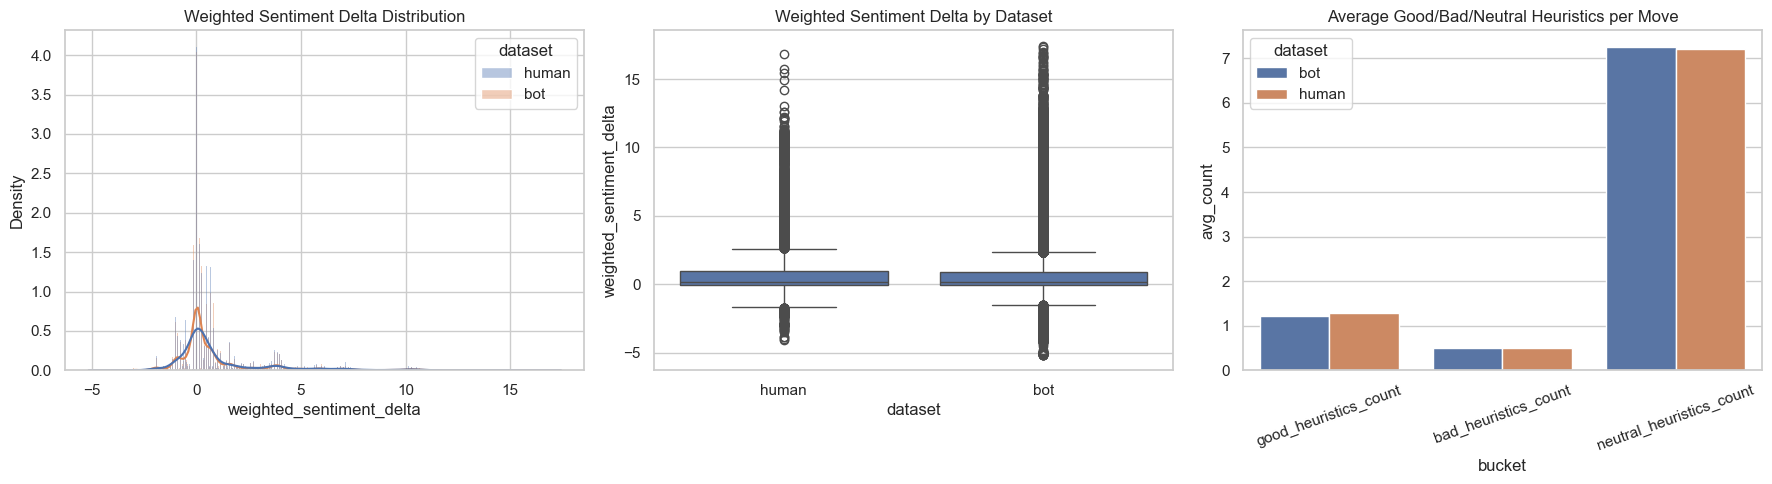

Per-heuristic good/bad/neutral rates:


,dataset,heuristic,good_rate,bad_rate,neutral_rate
7,bot,active_rooks_advantage,0.053586,0.019336,0.927078
2,bot,bishop_pair_advantage,0.022776,0.000013,0.977211
8,bot,development_advantage,0.218627,0.011188,0.770186
4,bot,doubled_pawns_disadvantage,0.004089,0.053044,0.942867
5,bot,isolated_pawns_disadvantage,0.033432,0.046925,0.919644
6,bot,king_pawn_shield_advantage,0.036279,0.133956,0.829765
0,bot,material_balance,0.225324,0.000000,0.774676
3,bot,passed_pawns_advantage,0.038988,0.006252,0.954760
1,bot,relative_mobility,0.596683,0.236440,0.166877
16,human,active_rooks_advantage,0.060320,0.018209,0.921471


In [19]:
# Positional Sentiment Calculation
import matplotlib.pyplot as plt
import seaborn as sns

# Heuristics that currently exist in your extracted move-feature data
heuristic_weights = {
    "material_balance": 1.0,
    "relative_mobility": 5.0,
    "bishop_pair_advantage": 2.0,
    "passed_pawns_advantage": 2.0,
    "doubled_pawns_disadvantage": 0.5,
    "isolated_pawns_disadvantage": 0.5,
    "king_pawn_shield_advantage": 1.0,
    "active_rooks_advantage": 1.5,
    "development_advantage": 0.5,
}

def build_sentiment_frame(df: pd.DataFrame, label: str) -> pd.DataFrame:
    out = df.copy()

    # Perspective: +1 for White mover, -1 for Black mover
    out["mover_sign"] = out["move_player"].map({"White": 1, "Black": -1}).fillna(1)

    delta_cols = []
    for metric, weight in heuristic_weights.items():
        before_col = f"before_{metric}"
        after_col = f"after_{metric}"

        mover_before_col = f"mover_before_{metric}"
        mover_after_col = f"mover_after_{metric}"
        delta_col = f"delta_{metric}"

        out[mover_before_col] = out[before_col] * out["mover_sign"]
        out[mover_after_col] = out[after_col] * out["mover_sign"]
        out[delta_col] = out[mover_after_col] - out[mover_before_col]
        delta_cols.append(delta_col)

    # Good / Bad / Neutral mapping per move
    out["good_heuristics_count"] = out[delta_cols].gt(0).sum(axis=1)
    out["bad_heuristics_count"] = out[delta_cols].lt(0).sum(axis=1)
    out["neutral_heuristics_count"] = out[delta_cols].eq(0).sum(axis=1)

    out["sentiment_raw"] = out["good_heuristics_count"] - out["bad_heuristics_count"]
    out["sentiment_norm"] = out["sentiment_raw"] / len(delta_cols)

    # Weighted sentiment delta
    out["weighted_sentiment_delta"] = 0.0
    for metric, weight in heuristic_weights.items():
        out["weighted_sentiment_delta"] += out[f"delta_{metric}"] * weight

    out["dataset"] = label
    return out

human_sentiment = build_sentiment_frame(df_human_move_features, "human")
bot_sentiment = build_sentiment_frame(df_bot_move_features, "bot")
combined_sentiment = pd.concat([human_sentiment, bot_sentiment], ignore_index=True)

# Quick summary table
summary = combined_sentiment.groupby("dataset")[[
    "good_heuristics_count",
    "bad_heuristics_count",
    "neutral_heuristics_count",
    "sentiment_raw",
    "sentiment_norm",
    "weighted_sentiment_delta",
]].agg(["mean", "median", "std"])

print("Move-level sentiment summary:")
display(summary)

# Distribution plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data=combined_sentiment,
    x="weighted_sentiment_delta",
    hue="dataset",
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title("Weighted Sentiment Delta Distribution")

sns.boxplot(
    data=combined_sentiment,
    x="dataset",
    y="weighted_sentiment_delta",
    ax=axes[1]
)
axes[1].set_title("Weighted Sentiment Delta by Dataset")

avg_counts = combined_sentiment.groupby("dataset")[[
    "good_heuristics_count", "bad_heuristics_count", "neutral_heuristics_count"
]].mean().reset_index().melt(id_vars="dataset", var_name="bucket", value_name="avg_count")

sns.barplot(
    data=avg_counts,
    x="bucket",
    y="avg_count",
    hue="dataset",
    ax=axes[2]
)
axes[2].set_title("Average Good/Bad/Neutral Heuristics per Move")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Optional: per-heuristic good/bad rates
delta_columns = [f"delta_{m}" for m in heuristic_weights]
rate_rows = []
for ds, dsub in combined_sentiment.groupby("dataset"):
    for dc in delta_columns:
        rate_rows.append({
            "dataset": ds,
            "heuristic": dc.replace("delta_", ""),
            "good_rate": (dsub[dc] > 0).mean(),
            "bad_rate": (dsub[dc] < 0).mean(),
            "neutral_rate": (dsub[dc] == 0).mean(),
        })
heuristic_rates = pd.DataFrame(rate_rows).sort_values(["dataset", "heuristic"])

print("Per-heuristic good/bad/neutral rates:")
display(heuristic_rates)


# Export Functions

In [21]:
# Export game data
df_human_games_meta.to_csv("../data/raw/human_games_metadata.csv", index=False)
df_bot_games_meta.to_csv("../data/raw/bot_games_metadata.csv", index=False)

# Export move data
df_human_move_features.to_csv("../data/raw/human_move_features.csv", index=False)
df_bot_move_features.to_csv("../data/raw/bot_move_features.csv", index=False)

# Export heuristic data
human_sentiment.to_csv("../data/raw/human_move_sentiment.csv", index=False)
bot_sentiment.to_csv("../data/raw/bot_move_sentiment.csv", index=False)
heuristic_rates.to_csv("../data/raw/heuristic_sentiment_rates.csv", index=False)

print("Data export complete!")

Data export complete!
